# <a id='toc1_'></a>[Calculating relative risk](#toc0_)

This notebook calculates the relative risk for each week, as well as risk classification (with and without zeros), using the following formula:

$\dfrac{\frac{R_{i, \ t}}{Cases_{i, \ t}}}{\frac{R_{\text{Total}, \ t}}{Cases_{\text{Total}, \ t}}}$

**Table of contents**<a id='toc0_'></a>    
- [Calculating relative risk](#toc1_)    
- [Loading datasets](#toc2_)    
- [Calculate relative dengue risk](#toc3_)    
- [Assign Classification ](#toc4_)    
    - [With zeros](#toc4_1_1_)    
    - [With no zeros](#toc4_1_2_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

# <a id='toc2_'></a>[Loading datasets](#toc0_)

In [ ]:
cases = pd.read_csv("../data/raw/cases_dengue_rr.csv")

In [34]:
cases.head()

,semana,0,1,101,102,103,104,105,106,107,...,611,7,701,702,703,704,705,706,99,98
0,2020-1,168,22,3,0,6,0,0,1,3,...,0,49,3,19,12,5,1,9,0,0
1,2020-2,171,30,11,0,5,1,0,3,3,...,1,52,5,25,8,3,2,9,0,0
2,2020-3,160,24,15,0,3,0,0,1,1,...,2,35,0,16,3,1,2,13,0,0
3,2020-4,154,18,7,0,2,4,0,0,2,...,1,30,4,9,7,3,2,5,0,0
4,2020-5,179,9,0,0,4,0,0,0,0,...,0,44,4,13,16,1,0,10,0,0


In [35]:
cases.shape

(312, 93)

In [ ]:
cases.drop(columns=["1", "2", "3", "4", "5", "6", "7", '99', '98'], inplace=True)

In [39]:
cases.head()

,semana,0,101,102,103,104,105,106,107,108,...,608,609,610,611,701,702,703,704,705,706
0,2020-1,168,3,0,6,0,0,1,3,0,...,0,0,2,0,3,19,12,5,1,9
1,2020-2,171,11,0,5,1,0,3,3,1,...,0,1,2,1,5,25,8,3,2,9
2,2020-3,160,15,0,3,0,0,1,1,0,...,1,0,2,2,0,16,3,1,2,13
3,2020-4,154,7,0,2,4,0,0,2,0,...,0,0,8,1,4,9,7,3,2,5
4,2020-5,179,0,0,4,0,0,0,0,0,...,0,2,3,0,4,13,16,1,0,10


In [40]:
cases.shape

(312, 84)

In [41]:
pob = pd.read_csv("../data/raw/pob_int_rr.csv")

In [42]:
pob.head()

,Unnamed: 0,0,101,102,103,104,105,106,107,108,...,611,612,613,701,702,703,704,705,706,week
0,1,5.036673e+06,348187.065287,69508.195025,239371.046869,38334.246828,17861.036746,61766.159934,28349.162705,137400.135631,...,25712.232557,4737.0745,12663.194213,93348.063664,149589.679738,56918.055352,43167.062246,44265.971385,55482.498262,2020-1
1,2,5.037255e+06,348205.384038,69514.321803,239393.593716,38337.715710,17861.718366,61770.803191,28350.926361,137410.919284,...,25723.426208,4737.5680,12668.044295,93344.614022,149615.150098,56917.406514,43177.962699,44271.029918,55495.259568,2020-2
2,3,5.037836e+06,348223.702790,69520.448582,239416.140563,38341.184593,17862.399986,61775.446448,28352.690016,137421.702937,...,25734.619858,4738.0615,12672.894377,93341.164380,149640.620459,56916.757675,43188.863153,44276.088451,55508.020874,2020-3
3,4,5.038418e+06,348242.021541,69526.575361,239438.687410,38344.653475,17863.081607,61780.089705,28354.453672,137432.486590,...,25745.813508,4738.5550,12677.744459,93337.714738,149666.090820,56916.108836,43199.763607,44281.146984,55520.782180,2020-4
4,5,5.039000e+06,348260.340292,69532.702139,239461.234257,38348.122358,17863.763227,61784.732962,28356.217328,137443.270243,...,25757.007158,4739.0485,12682.594541,93334.265096,149691.561180,56915.459997,43210.664060,44286.205516,55533.543486,2020-5


In [43]:
pob.drop(["Unnamed: 0", "612", "613"], axis = 1, inplace = True)

In [44]:
pob = pob.rename(columns = {"week": "semana"})

In [45]:
pob_weeks = pd.DataFrame(pob["semana"])

In [46]:
pob.drop(columns = "semana")

,0,101,102,103,104,105,106,107,108,109,...,608,609,610,611,701,702,703,704,705,706
0,5.036673e+06,348187.065287,69508.195025,239371.046869,38334.246828,17861.036746,61766.159934,28349.162705,137400.135631,59583.184549,...,36396.931762,20980.987992,52067.497025,25712.232557,93348.063664,149589.679738,56918.055352,43167.062246,44265.971385,55482.498262
1,5.037255e+06,348205.384038,69514.321803,239393.593716,38337.715710,17861.718366,61770.803191,28350.926361,137410.919284,59592.646273,...,36394.555568,20986.419399,52072.720803,25723.426208,93344.614022,149615.150098,56917.406514,43177.962699,44271.029918,55495.259568
2,5.037836e+06,348223.702790,69520.448582,239416.140563,38341.184593,17862.399986,61775.446448,28352.690016,137421.702937,59602.107997,...,36392.179374,20991.850806,52077.944582,25734.619858,93341.164380,149640.620459,56916.757675,43188.863153,44276.088451,55508.020874
3,5.038418e+06,348242.021541,69526.575361,239438.687410,38344.653475,17863.081607,61780.089705,28354.453672,137432.486590,59611.569721,...,36389.803180,20997.282213,52083.168361,25745.813508,93337.714738,149666.090820,56916.108836,43199.763607,44281.146984,55520.782180
4,5.039000e+06,348260.340292,69532.702139,239461.234257,38348.122358,17863.763227,61784.732962,28356.217328,137443.270243,59621.031445,...,36387.426986,21002.713620,52088.392139,25757.007158,93334.265096,149691.561180,56915.459997,43210.664060,44286.205516,55533.543486
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,5.202500e+06,353551.701784,71315.489014,245490.818745,39277.237759,18021.397340,62916.251112,28829.509485,140355.115205,62312.878984,...,35496.848970,22653.307386,53446.082896,29102.376822,91946.284877,156621.214123,57133.587140,46351.107225,45565.657882,59056.068553
308,5.202989e+06,353567.359767,71320.748027,245507.502890,39279.853918,18021.759479,62919.049425,28830.678370,140363.202411,62320.811767,...,35492.956740,22658.742973,53449.804192,29113.179644,91940.876753,156641.371247,57134.394479,46361.211849,45569.209164,59066.767507
309,5.203477e+06,353583.017751,71326.007041,245524.187036,39282.470077,18022.121619,62921.847737,28831.847255,140371.289616,62328.744551,...,35489.064510,22664.178559,53453.525488,29123.982466,91935.468630,156661.528370,57135.201819,46371.316474,45572.760447,59077.466460
310,5.203966e+06,353598.675734,71331.266055,245540.871181,39285.086236,18022.483759,62924.646049,28833.016140,140379.376822,62336.677334,...,35485.172279,22669.614145,53457.246784,29134.785288,91930.060507,156681.685493,57136.009159,46381.421099,45576.311729,59088.165414


In [47]:
pob = pd.concat([pob_weeks, pob], axis = 1)

In [48]:
pob.head()

,semana,0,101,102,103,104,105,106,107,108,...,609,610,611,701,702,703,704,705,706,semana
0,2020-1,5.036673e+06,348187.065287,69508.195025,239371.046869,38334.246828,17861.036746,61766.159934,28349.162705,137400.135631,...,20980.987992,52067.497025,25712.232557,93348.063664,149589.679738,56918.055352,43167.062246,44265.971385,55482.498262,2020-1
1,2020-2,5.037255e+06,348205.384038,69514.321803,239393.593716,38337.715710,17861.718366,61770.803191,28350.926361,137410.919284,...,20986.419399,52072.720803,25723.426208,93344.614022,149615.150098,56917.406514,43177.962699,44271.029918,55495.259568,2020-2
2,2020-3,5.037836e+06,348223.702790,69520.448582,239416.140563,38341.184593,17862.399986,61775.446448,28352.690016,137421.702937,...,20991.850806,52077.944582,25734.619858,93341.164380,149640.620459,56916.757675,43188.863153,44276.088451,55508.020874,2020-3
3,2020-4,5.038418e+06,348242.021541,69526.575361,239438.687410,38344.653475,17863.081607,61780.089705,28354.453672,137432.486590,...,20997.282213,52083.168361,25745.813508,93337.714738,149666.090820,56916.108836,43199.763607,44281.146984,55520.782180,2020-4
4,2020-5,5.039000e+06,348260.340292,69532.702139,239461.234257,38348.122358,17863.763227,61784.732962,28356.217328,137443.270243,...,21002.713620,52088.392139,25757.007158,93334.265096,149691.561180,56915.459997,43210.664060,44286.205516,55533.543486,2020-5


In [49]:
pob.shape

(312, 85)

In [50]:
pob.head()

,semana,0,101,102,103,104,105,106,107,108,...,609,610,611,701,702,703,704,705,706,semana
0,2020-1,5.036673e+06,348187.065287,69508.195025,239371.046869,38334.246828,17861.036746,61766.159934,28349.162705,137400.135631,...,20980.987992,52067.497025,25712.232557,93348.063664,149589.679738,56918.055352,43167.062246,44265.971385,55482.498262,2020-1
1,2020-2,5.037255e+06,348205.384038,69514.321803,239393.593716,38337.715710,17861.718366,61770.803191,28350.926361,137410.919284,...,20986.419399,52072.720803,25723.426208,93344.614022,149615.150098,56917.406514,43177.962699,44271.029918,55495.259568,2020-2
2,2020-3,5.037836e+06,348223.702790,69520.448582,239416.140563,38341.184593,17862.399986,61775.446448,28352.690016,137421.702937,...,20991.850806,52077.944582,25734.619858,93341.164380,149640.620459,56916.757675,43188.863153,44276.088451,55508.020874,2020-3
3,2020-4,5.038418e+06,348242.021541,69526.575361,239438.687410,38344.653475,17863.081607,61780.089705,28354.453672,137432.486590,...,20997.282213,52083.168361,25745.813508,93337.714738,149666.090820,56916.108836,43199.763607,44281.146984,55520.782180,2020-4
4,2020-5,5.039000e+06,348260.340292,69532.702139,239461.234257,38348.122358,17863.763227,61784.732962,28356.217328,137443.270243,...,21002.713620,52088.392139,25757.007158,93334.265096,149691.561180,56915.459997,43210.664060,44286.205516,55533.543486,2020-5


In [ ]:
# One of the columns has whitespace, so it has to be stripped to avoid errors in the division operation.
pob.columns = pob.columns.str.strip()

# <a id='toc3_'></a>[Calculate relative dengue risk](#toc0_)

In [ ]:
# Calculate relative risk numerator by dividing cases by population for each week and canton
# The week column has to be dropped from the calculation because it is not a numeric value and cannot be used in the division operation.
relative_risk_num = cases.drop("semana", axis = 1).div(pob.drop("semana", axis = 1), axis="columns")

In [ ]:
# Check if the relative risk numerator has been calculated correctly by looking at the last few rows of the dataframe.
relative_risk_num.tail()

,0,101,102,103,104,105,106,107,108,109,...,608,609,610,611,701,702,703,704,705,706
307,0.000032,0.000068,0.000028,0.000004,0.0,0.000055,0.000016,0.000000,0.000000,0.000080,...,0.0,0.000000,0.000000,0.000103,0.000022,0.000019,0.000018,0.000000,0.000000,0.000017
308,0.000037,0.000088,0.000042,0.000012,0.0,0.000000,0.000016,0.000000,0.000007,0.000064,...,0.0,0.000000,0.000019,0.000069,0.000011,0.000026,0.000018,0.000000,0.000022,0.000017
309,0.000042,0.000102,0.000000,0.000008,0.0,0.000000,0.000016,0.000000,0.000000,0.000112,...,0.0,0.000000,0.000000,0.000069,0.000011,0.000070,0.000035,0.000086,0.000088,0.000000
310,0.000035,0.000082,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000021,0.000096,...,0.0,0.000088,0.000000,0.000034,0.000022,0.000000,0.000018,0.000065,0.000044,0.000000
311,0.000021,0.000014,0.000000,0.000004,0.0,0.000000,0.000016,0.000104,0.000000,0.000000,...,0.0,0.000265,0.000019,0.000206,0.000033,0.000000,0.000000,0.000022,0.000000,0.000000


In [ ]:
# Calculate relative risk denominator by dividing total cases by total population for each week and canton
relative_risk_den = cases["0"].div(pob["0"], axis="index")

In [55]:
relative_risk_den.head()

0    0.000033
1    0.000034
2    0.000032
3    0.000031
4    0.000036
Name: 0, dtype: float64

In [ ]:
# Divide numerator by denominator to get relative risk for each week and canton
# axis = "index" is used to align the dataframes by their index (week) when performing the division operation.
relative_risk = relative_risk_num.div(relative_risk_den, axis="index")

In [57]:
relative_risk.tail()

,0,101,102,103,104,105,106,107,108,109,...,608,609,610,611,701,702,703,704,705,706
307,1.0,2.089699,0.863319,0.125398,0.0,1.708193,0.489286,0.000000,0.000000,2.470117,...,0.0,0.000000,0.000000,3.173352,0.669609,0.589652,0.538808,0.000000,0.000000,0.521268
308,1.0,2.400982,1.151873,0.334623,0.0,0.000000,0.435228,0.000000,0.195095,1.757625,...,0.0,0.000000,0.512334,1.881220,0.297845,0.699283,0.479294,0.000000,0.600935,0.463614
309,1.0,2.408142,0.000000,0.192667,0.0,0.000000,0.375898,0.000000,0.000000,2.656322,...,0.0,0.000000,0.000000,1.624240,0.257269,1.660739,0.827937,2.040241,2.075992,0.000000
310,1.0,2.357997,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.614432,2.767346,...,0.0,2.536540,0.000000,0.986834,0.625501,0.000000,0.503206,1.859658,1.261673,0.000000
311,1.0,0.668995,0.000000,0.192677,0.0,0.000000,0.751869,4.922618,0.000000,0.000000,...,0.0,12.519458,0.885005,9.740045,1.544087,0.000000,0.000000,1.019868,0.000000,0.000000


In [58]:
relative_risk.drop(columns=["0"], inplace=True)

In [ ]:
# Add the semana column back to the relative risk dataframe to have the week information for each row
relative_risk["semana"] = cases["semana"]

In [60]:
relative_risk

,101,102,103,104,105,106,107,108,109,110,...,609,610,611,701,702,703,704,705,706,semana
0,0.258311,0.000000,0.751474,0.000000,0.000000,0.485382,3.172601,0.000000,0.503165,1.287761,...,0.000000,1.151590,0.000000,0.963497,3.807908,6.320707,3.472578,0.677274,4.863187,2020-1
1,0.930583,0.000000,0.615255,0.768372,0.000000,1.430658,3.117108,0.214376,0.494317,1.265095,...,1.403652,1.131404,1.145167,1.577897,4.922234,4.140404,2.046713,1.330786,4.777321,2020-2
2,1.356304,0.000000,0.394541,0.000000,0.000000,0.509692,1.110529,0.000000,0.528278,0.000000,...,0.000000,1.209206,2.447013,0.000000,3.366624,1.659607,0.729042,1.422279,7.374145,2020-3
3,0.657643,0.000000,0.273281,3.412940,0.000000,0.000000,2.307715,0.000000,1.097673,0.000000,...,0.000000,5.025347,1.270770,1.402091,1.967400,4.023799,2.272026,1.477694,2.946374,2020-4
4,0.000000,0.000000,0.470236,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.302086,...,2.680686,1.621331,0.000000,1.206452,2.444766,7.913726,0.651479,0.000000,5.069159,2020-5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307,2.089699,0.863319,0.125398,0.000000,1.708193,0.489286,0.000000,0.000000,2.470117,0.314820,...,0.000000,0.000000,3.173352,0.669609,0.589652,0.538808,0.000000,0.000000,0.521268,2025-48
308,2.400982,1.151873,0.334623,0.000000,0.000000,0.435228,0.000000,0.195095,1.757625,0.840030,...,0.000000,0.512334,1.881220,0.297845,0.699283,0.479294,0.000000,0.600935,0.463614,2025-49
309,2.408142,0.000000,0.192667,0.000000,0.000000,0.375898,0.000000,0.000000,2.656322,0.483629,...,0.000000,0.000000,1.624240,0.257269,1.660739,0.827937,2.040241,2.075992,0.000000,2025-50
310,2.357997,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.614432,2.767346,2.351227,...,2.536540,0.000000,0.986834,0.625501,0.000000,0.503206,1.859658,1.261673,0.000000,2025-51


In [ ]:
# Save the relative risk in the correct format for the EDA report
relative_risk.to_csv("../data/interim/eda/relative_risk_eda.csv", index=False)

In [ ]:
# Change relative risk dataframe so the rows are the week-canton pairs
relative_risk = pd.melt(relative_risk , id_vars="semana", var_name = "canton", value_name="rr")
relative_risk ["week-canton"] = relative_risk ["semana"] + "-" + relative_risk ["canton"].astype(str)
relative_risk .drop(columns=["semana", "canton"], inplace=True)

# <a id='toc4_'></a>[Assign Classification](#toc1_)  [&#8593;](#toc0_)

### <a id='toc4_1_1_'></a>[With zeros](#toc0_)

In [ ]:
# Calculate the thresholds for low and high relative risk using the 30th and 70th percentiles, respectively.
low_thresh = np.nanpercentile(relative_risk["rr"], q = 30)
medium_thresh = np.nanpercentile(relative_risk["rr"], q = 70)

relative_risk["clasi_rr"] = np.where(relative_risk["rr"] <= low_thresh, "Bajo", np.where(relative_risk["rr"] >= medium_thresh, "Alto", "Medio"))

In [32]:
relative_risk.head()

,rr,week-canton,clasi_rr
0,0.258311,2020-1-101,Medio
1,0.930583,2020-2-101,Alto
2,1.356304,2020-3-101,Alto
3,0.657643,2020-4-101,Alto
4,0.000000,2020-5-101,Bajo


In [33]:
relative_risk.tail()

,rr,week-canton,clasi_rr
25579,0.521268,2025-48-706,Alto
25580,0.463614,2025-49-706,Medio
25581,0.000000,2025-50-706,Bajo
25582,0.000000,2025-51-706,Bajo
25583,0.000000,2025-52-706,Bajo


In [ ]:
relative_risk.to_csv("../data/interim/relative_risk.csv", index=False)

### <a id='toc4_1_2_'></a>[With no zeros](#toc0_)

In [ ]:
rr = pd.read_csv("../data/interim/relative_risk.csv")

In [ ]:
rr_no_0 = rr[rr["rr"] != 0]

low_thresh_no_0 = np.nanpercentile(rr_no_0["rr"], q = 30)
medium_thresh_no_0 = np.nanpercentile(rr_no_0["rr"], q = 70)

rr["clasi_rr_no_0"] = np.where(rr["rr"] <= low_thresh_no_0, "Bajo", np.where(rr["rr"] >= medium_thresh_no_0, "Alto", "Medio"))

In [ ]:
cases = pd.read_csv("../data/interim/cases_dengue_rr.csv")

In [ ]:
print("Umbral bajo (con ceros):", low_thresh)
print("Umbral medio (con ceros):", medium_thresh)
print("Umbral bajo (sin ceros):", low_thresh_no_0) 
print("Umbral medio (sin ceros):", medium_thresh_no_0)

Umbral bajo (con ceros): 0.0
Umbral medio (con ceros): 0.4991877071268368
Umbral bajo (sin ceros): 0.6008728528017555
Umbral medio (sin ceros): 2.406536561969426


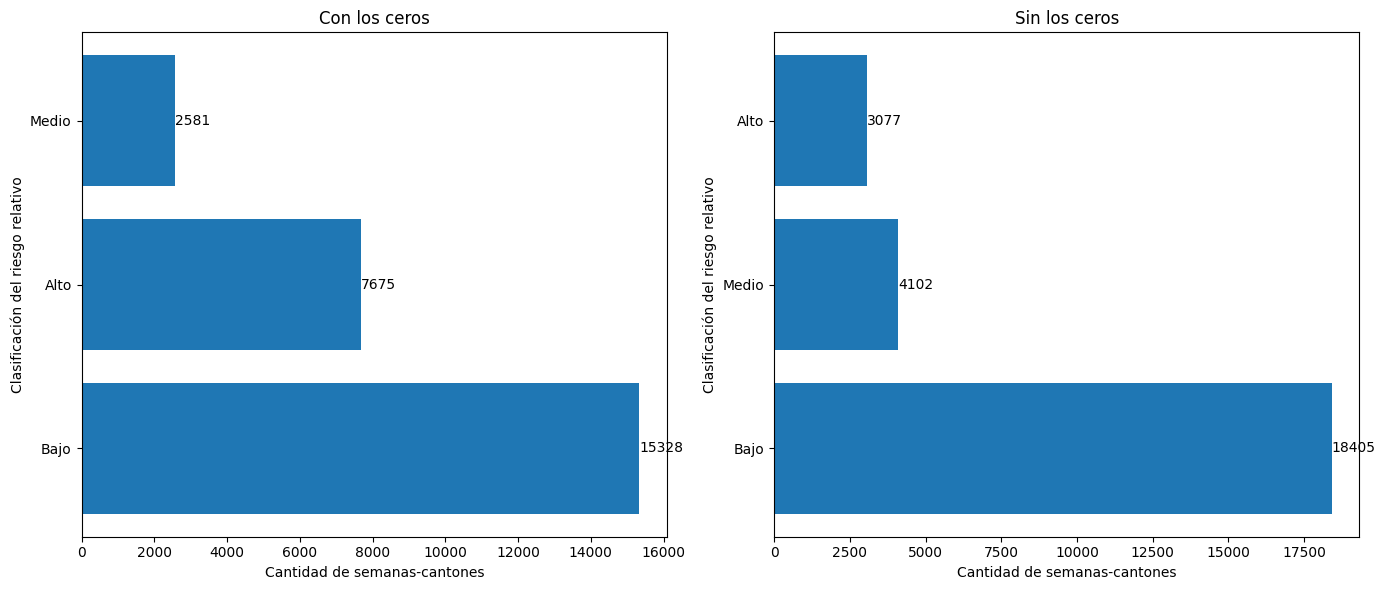

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

rr_clasi_0 = rr["clasi_rr"].value_counts()
bars1 = ax[0].barh(rr_clasi_0.index, rr_clasi_0.values)
ax[0].bar_label(bars1)
ax[0].set_xlabel("Cantidad de semanas-cantones")
ax[0].set_ylabel("Clasificación del riesgo relativo")
ax[0].set_title('Con los ceros')

rr_clasi_no_0 = rr["clasi_rr_no_0"].value_counts()
bars2 = ax[1].barh(rr_clasi_no_0.index, rr_clasi_no_0.values)
ax[1].bar_label(bars2)
ax[1].set_xlabel("Cantidad de semanas-cantones")
ax[1].set_ylabel("Clasificación del riesgo relativo")
ax[1].set_title('Sin los ceros')

plt.tight_layout()
plt.show()

In [12]:
rr.head()

,rr,week-canton,clasi_rr,clasi_rr_no_0
0,0.258311,2020-1-101,Medio,Bajo
1,0.930583,2020-2-101,Alto,Medio
2,1.356304,2020-3-101,Alto,Medio
3,0.657643,2020-4-101,Alto,Medio
4,0.000000,2020-5-101,Bajo,Bajo


In [ ]:
rr.to_csv("../data/interim/relative_risk.csv")